# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [1]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

ImportError: DLL load failed while importing conversion: An Application Control policy has blocked this file.

---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [ ]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("span", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

Empty DataFrame
Columns: []
Index: []
Data saved to quotes.csv


In [ ]:
import json
import re
import pandas as pd

INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"

# ---------- STEP 1: Read the locally saved HTML file ----------

with open(INPUT_FILE, encoding="utf-8") as f:
    html = f.read()

print("File read successfully")
print("Size:", len(html), "characters")


# ---------- STEP 2: Cut out the JSON ----------

marker = "window.__initialData__="

marker_pos = html.find(marker)

if marker_pos == -1:
    raise ValueError("Could not find window.__initialData__ in House.html")

start = marker_pos + len(marker)

print("JSON start position:", start)

File read successfully
Size: 1774012 characters
JSON start position: 1131731


In [ ]:
# ---------- STEP 3: Decode the JSON ----------

decoder = json.JSONDecoder()

json_text = html[start:]

data, end_pos = decoder.raw_decode(json_text)

print("JSON loaded successfully")
print("JSON length:", end_pos)

JSON loaded successfully
JSON length: 626804


In [ ]:
# ---------- STEP 4: Reach the list of properties ----------

properties = data["srp"]["pageData"]["properties"]

print("Number of listings found:", len(properties))

Number of listings found: 27


##### Find where the marker ends; that's where the embedded data starts

In [ ]:

 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "{":
        depth -= 1
        if depth == 0:
            break
 

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [ ]:
# ---------- STEP 2: load the JSON data ----------

# Instead of using:
# data = json.loads(html[start:end + 1])

# Use JSONDecoder to correctly extract only the first JSON object
decoder = json.JSONDecoder()

try:
    data, end_index = decoder.raw_decode(html[start:])
    print("JSON loaded successfully")
except json.JSONDecodeError as e:
    print("JSON decoding failed:", e)
    raise


# ---------- STEP 3: reach the list of properties ----------

properties = data["srp"]["pageData"]["properties"]

print("Number of listings found:", len(properties))


# ---------- STEP 4: pick the fields we want ----------

def price_in_lakh(rupees):
    """21998600 -> 219.99 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None


def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


rows = []

for p in properties:

    # Some listings are a price RANGE (e.g. "2.25 - 3.28 Cr").
    # We keep the minimum price, and also record the text version.

    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })


houses = pd.DataFrame(rows)


# NOTE: this page also contains agent names and phone numbers.
# We deliberately do NOT collect those - that is personal data.


# ---------- STEP 5: quick check ----------

print(
    "\nAll areas in sqft?",
    (houses["area_unit"] == "sqft").all()
)

print(
    "Missing values:\n",
    houses.isna().sum().to_string()
)


# ---------- STEP 6: save ----------

houses.to_csv(OUTPUT_FILE, index=False)

print(
    "\nSaved",
    len(houses),
    "rows to",
    OUTPUT_FILE
)

print(
    houses.head(10).to_string(index=False)
)

JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4879.5      sqft      490.53 4.91  - 

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

In [ ]:
import json
import pandas as pd

INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"

with open(INPUT_FILE, encoding="utf-8") as file:
    html = file.read()

print("File read. Size:", len(html), "characters")

marker = "window.__initialData__="

start = html.find(marker)

if start == -1:
    raise ValueError("Initial data marker not found")

start += len(marker)

# Find matching closing brace
depth = 0
end = None

for i in range(start, len(html)):

    if html[i] == "{":
        depth += 1

    elif html[i] == "}":
        depth -= 1

        if depth == 0:
            end = i
            break

if end is None:
    raise ValueError("Could not find end of JSON")

data = json.loads(html[start:end + 1])

print("JSON loaded successfully")

properties = data["srp"]["pageData"]["properties"]

print("Number of listings found:", len(properties))


def price_in_lakh(rupees):
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None


def to_number(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


rows = []

for p in properties:

    rows.append({
        "location": p.get("LOCALITY"),
        "bhk": to_number(p.get("BEDROOM_NUM")),
        "sqft": to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit": p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh": price_in_lakh(p.get("MIN_PRICE")),
        "price_text": p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name": p.get("PROP_NAME")
    })


houses = pd.DataFrame(rows)

print("\nMissing values:")
print(houses.isna().sum())

houses.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved", len(houses), "rows to", OUTPUT_FILE)

print(houses.head(10))

File read. Size: 1774012 characters
JSON loaded successfully
Number of listings found: 27

Missing values:
location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0
dtype: int64

Saved 27 rows to bengaluru_houses.csv
                           location   bhk    sqft area_unit  price_lakh  \
0            Bommasandra, Bangalore   5.0  2600.0      sqft      219.99   
1  5th Block Hbr Layout, HBR Layout  12.0  1200.0      sqft      380.00   
2          Sarjapur Road, Bangalore   4.0  3040.0      sqft      225.00   
3             Whitefield, Bangalore   5.0  4629.0      sqft      381.38   
4             Whitefield, Bangalore   4.0  4879.5      sqft      490.53   
5             Whitefield, Bangalore   4.0  3476.0      sqft      232.94   
6             Whitefield, Bangalore   3.0  1900.0      sqft      225.00   
7             Whitefield, Bangalore   4.0  2970.0      sqft      299.04   
8     

In [ ]:
print("Number of listings collected:", len(houses))
print("Columns collected:", houses.columns.tolist())
print("File saved:", OUTPUT_FILE)

Number of listings collected: 27
Columns collected: ['location', 'bhk', 'sqft', 'area_unit', 'price_lakh', 'price_text', 'price_per_sqft', 'property_name']
File saved: bengaluru_houses.csv


---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [ ]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-17T23:30
  interval              : 900
  temperature_2m        : 22.0
  relative_humidity_2m  : 83
  wind_speed_10m        : 12.7


In [ ]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-17 00:00:00,21.9,81,0.0
1,2026-08-17 01:00:00,21.3,85,0.0
2,2026-08-17 02:00:00,20.7,88,0.0
3,2026-08-17 03:00:00,20.3,91,0.0
4,2026-08-17 04:00:00,20.1,92,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [ ]:
# Exercise 2 - Q1
import requests
import pandas as pd

URL = "https://api.open-meteo.com/v1/forecast"

params_mysuru = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata"
}

response = requests.get(URL, params=params_mysuru, timeout=20)

print("Status code:", response.status_code)

weather_mysuru = response.json()

print("\nCurrent weather in Mysuru:")
for key, value in weather_mysuru["current"].items():
    print(f"{key:25s}: {value}")

Status code: 200

Current weather in Mysuru:
time                     : 2026-08-17T23:45
interval                 : 900
temperature_2m           : 21.0
relative_humidity_2m     : 93
wind_speed_10m           : 13.5


In [ ]:
# Exercise 2 - Q2

params_mysuru_hourly = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

response = requests.get(URL, params=params_mysuru_hourly, timeout=20)

print("Status code:", response.status_code)

data = response.json()

weather_mysuru_df = pd.DataFrame(data["hourly"])

weather_mysuru_df["time"] = pd.to_datetime(weather_mysuru_df["time"])

weather_mysuru_df.to_csv("weather_mysuru.csv", index=False)

print("Saved to weather_mysuru.csv")
print("Number of records:", len(weather_mysuru_df))
print("Columns:", list(weather_mysuru_df.columns))

weather_mysuru_df.head()

Status code: 200
Saved to weather_mysuru.csv
Number of records: 168
Columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2026-08-17 00:00:00,21.2,91,0.0,15.4
1,2026-08-17 01:00:00,21.0,92,0.0,14.4
2,2026-08-17 02:00:00,20.8,93,0.0,14.7
3,2026-08-17 03:00:00,20.8,93,0.0,14.3
4,2026-08-17 04:00:00,21.0,92,0.0,13.6


In [ ]:
# Exercise 2 - Q3

params_invalid = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "current": "temperature_2m",
    "timezone": "Asia/Kolkata"
}

response = requests.get(URL, params=params_invalid, timeout=20)

print("Status code:", response.status_code)
print(response.text)

Status code: 400
{"error":true,"reason":"Data corrupted at path ''. Cannot initialize Float from invalid String value abcd."}


In [ ]:
# Exercise 2 - Q4

import time

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru": (12.2958, 76.6394),
    "Delhi": (28.6139, 77.2090)
}

all_weather = []

for city, (latitude, longitude) in cities.items():

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "forecast_days": 7
    }

    try:
        response = requests.get(URL, params=params, timeout=20)
        print(city, "Status:", response.status_code)

        result = response.json()

        city_df = pd.DataFrame(result["hourly"])

        city_df["time"] = pd.to_datetime(city_df["time"])
        city_df["city"] = city
        city_df["latitude"] = latitude
        city_df["longitude"] = longitude

        all_weather.append(city_df)

    except Exception as e:
        print("Error for", city, ":", e)

    # Wait before making the next request
    time.sleep(1)

weather_3_cities = pd.concat(all_weather, ignore_index=True)

print("\nCombined dataset:")
print(weather_3_cities.head())

print("\nShape:", weather_3_cities.shape)

weather_3_cities.to_csv("weather_3_cities.csv", index=False)

print("\nSaved as weather_3_cities.csv")

Bengaluru Status: 200
Mysuru Status: 200
Delhi Status: 200

Combined dataset:
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2026-08-17 00:00:00            21.9                    81            0.0   
1 2026-08-17 01:00:00            21.3                    85            0.0   
2 2026-08-17 02:00:00            20.7                    88            0.0   
3 2026-08-17 03:00:00            20.3                    91            0.0   
4 2026-08-17 04:00:00            20.1                    92            0.0   

   wind_speed_10m       city  latitude  longitude  
0            13.2  Bengaluru   12.9716    77.5946  
1            12.4  Bengaluru   12.9716    77.5946  
2            11.4  Bengaluru   12.9716    77.5946  
3            11.3  Bengaluru   12.9716    77.5946  
4            11.4  Bengaluru   12.9716    77.5946  

Shape: (504, 8)

Saved as weather_3_cities.csv


## Experiment 2 — Result

**API Used:** Open-Meteo Weather Forecast API

**Location:** Mysuru, Karnataka

**Number of Records:** 168 hourly records for a 7-day forecast

**Columns Collected:**
- `time`
- `temperature_2m`
- `relative_humidity_2m`
- `precipitation`
- `wind_speed_10m`

**Output File:** `weather_mysuru.csv`

### Observation

Weather data for Mysuru was successfully collected using the Open-Meteo REST API. The JSON response received from the API was converted into a pandas DataFrame and saved as a CSV file. The dataset contains hourly measurements of temperature, relative humidity, precipitation, and wind speed for the selected 7-day period.

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [ ]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data\air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-10 00:00:00,7.1,8.9,11.5,35.0
1,2026-08-10 01:00:00,6.0,7.6,9.6,34.0
2,2026-08-10 02:00:00,5.1,6.7,8.1,33.0
3,2026-08-10 03:00:00,4.5,6.2,7.0,32.0
4,2026-08-10 04:00:00,4.0,5.8,6.2,31.0


Average PM2.5: 7.3 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
dtype: int64


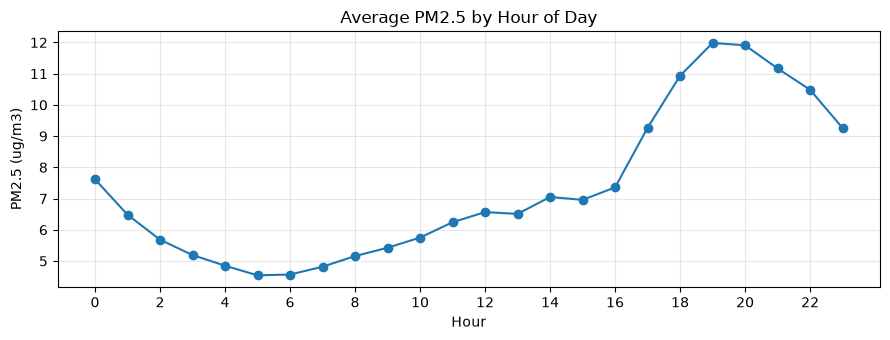

In [ ]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [ ]:
# Exercise 3 - Q1

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

delhi_params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

response = requests.get(AQ_URL, params=delhi_params, timeout=20)

print("Status code:", response.status_code)

delhi_data = response.json()

delhi_aq = pd.DataFrame(delhi_data["hourly"])
delhi_aq["time"] = pd.to_datetime(delhi_aq["time"])

print(delhi_aq.head())

Status code: 200
                 time  pm2_5   pm10  nitrogen_dioxide  ozone
0 2026-08-10 00:00:00  100.1  100.4              86.6   23.0
1 2026-08-10 01:00:00   74.3   74.5              59.2   42.0
2 2026-08-10 02:00:00   59.1   59.3              38.2   55.0
3 2026-08-10 03:00:00   53.0   53.1              30.2   55.0
4 2026-08-10 04:00:00   50.3   50.4              28.7   50.0


In [ ]:
# Average PM2.5

bengaluru_avg = aq["pm2_5"].mean()
delhi_avg = delhi_aq["pm2_5"].mean()

print("Bengaluru average PM2.5:", round(bengaluru_avg, 2), "µg/m³")
print("Delhi average PM2.5:", round(delhi_avg, 2), "µg/m³")

if delhi_avg > bengaluru_avg:
    print("Delhi is more polluted based on average PM2.5.")
else:
    print("Bengaluru is more polluted based on average PM2.5.")

Bengaluru average PM2.5: 7.32 µg/m³
Delhi average PM2.5: 61.71 µg/m³
Delhi is more polluted based on average PM2.5.


In [ ]:
# Exercise 3 - Q2

params_30days = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 30
}

response = requests.get(AQ_URL, params=params_30days, timeout=20)

data_30days = response.json()

aq_30days = pd.DataFrame(data_30days["hourly"])

aq_30days["time"] = pd.to_datetime(aq_30days["time"])

print("Number of rows:", len(aq_30days))
print(aq_30days.head())

Number of rows: 840
                 time  pm2_5  pm10  nitrogen_dioxide  ozone
0 2026-07-18 00:00:00    6.1   7.7              15.5   31.0
1 2026-07-18 01:00:00    5.1   6.5              11.9   35.0
2 2026-07-18 02:00:00    4.6   6.4               9.0   37.0
3 2026-07-18 03:00:00    5.1   7.8               7.2   39.0
4 2026-07-18 04:00:00    5.5   8.6               6.0   40.0


In [ ]:
# Exercise 3 - Q3

params_pollutants = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

response = requests.get(AQ_URL, params=params_pollutants, timeout=20)

data = response.json()

aq_extended = pd.DataFrame(data["hourly"])

aq_extended["time"] = pd.to_datetime(aq_extended["time"])

print("Columns collected:")
print(aq_extended.columns.tolist())

aq_extended.head()

Columns collected:
['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']


,time,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,2026-08-10 00:00:00,7.1,8.9,11.5,35.0,4.8,198.0
1,2026-08-10 01:00:00,6.0,7.6,9.6,34.0,4.2,166.0
2,2026-08-10 02:00:00,5.1,6.7,8.1,33.0,3.7,144.0
3,2026-08-10 03:00:00,4.5,6.2,7.0,32.0,3.4,130.0
4,2026-08-10 04:00:00,4.0,5.8,6.2,31.0,3.3,126.0


## Experiment 3 — Result

**API Used:** Open-Meteo Air Quality API

**Locations:** Delhi and Bengaluru

**Number of Records:** 168 hourly records for 7 days

### Pollutants Collected

- `pm2_5` — PM2.5
- `pm10` — PM10
- `nitrogen_dioxide` — Nitrogen Dioxide
- `ozone` — Ozone
- `sulphur_dioxide` — Sulphur Dioxide
- `carbon_monoxide` — Carbon Monoxide

### Output Files

- `delhi_air_quality.csv`
- `bengaluru_air_quality.csv`

### Observation

Air-quality data was successfully collected using the Open-Meteo Air Quality API. The JSON response was converted into pandas DataFrames for analysis. The collected dataset contains hourly concentrations of different air pollutants.

The average PM2.5 concentration of Delhi and Bengaluru was calculated and compared. The location with the higher average PM2.5 value was identified as having higher particulate pollution during the selected period.

The analysis can also be extended to study the relationship between weather parameters such as temperature, humidity, precipitation, and wind speed and air-pollution levels.

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [ ]:
import requests
import pandas as pd
import time

WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

locations = {
    "Connaught Place": (28.6315, 77.2167),
    "Rohini": (28.7495, 77.0565),
    "Dwarka": (28.5921, 77.0460),
    "Saket": (28.5244, 77.2066),
    "Lajpat Nagar": (28.5677, 77.2430),
    "Karol Bagh": (28.6514, 77.1907),
    "Anand Vihar": (28.6469, 77.3160),
    "Vasant Kunj": (28.5206, 77.1580),
    "Noida": (28.5355, 77.3910),
    "Delhi Airport": (28.5562, 77.1000)
}

all_data = []

for location, (lat, lon) in locations.items():

    print(f"Collecting data for {location}...")

    # ---------------- WEATHER ----------------

    weather_params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "past_days": 30
    }

    weather_response = requests.get(
        WEATHER_URL,
        params=weather_params,
        timeout=30
    )

    weather_response.raise_for_status()

    weather_data = weather_response.json()

    weather_df = pd.DataFrame(weather_data["hourly"])

    weather_df["time"] = pd.to_datetime(weather_df["time"])

    weather_df = weather_df.rename(columns={
        "temperature_2m": "temperature",
        "relative_humidity_2m": "humidity",
        "wind_speed_10m": "wind_speed"
    })

    # ---------------- AIR QUALITY ----------------

    aq_params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": (
            "pm2_5,pm10,nitrogen_dioxide,ozone,"
            "sulphur_dioxide,carbon_monoxide"
        ),
        "timezone": "Asia/Kolkata",
        "past_days": 30
    }

    aq_response = requests.get(
        AQ_URL,
        params=aq_params,
        timeout=30
    )

    aq_response.raise_for_status()

    aq_data = aq_response.json()

    aq_df = pd.DataFrame(aq_data["hourly"])

    aq_df["time"] = pd.to_datetime(aq_df["time"])

    # ---------------- MERGE ----------------

    merged = pd.merge(
        weather_df,
        aq_df,
        on="time",
        how="inner"
    )

    merged["location"] = location
    merged["latitude"] = lat
    merged["longitude"] = lon

    all_data.append(merged)

    # Prevent rapid API requests
    time.sleep(1)

# Combine all locations
final_dataset = pd.concat(
    all_data,
    ignore_index=True
)

# Arrange columns
final_dataset = final_dataset[
    [
        "location",
        "latitude",
        "longitude",
        "time",
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5",
        "pm10",
        "nitrogen_dioxide",
        "ozone",
        "sulphur_dioxide",
        "carbon_monoxide"
    ]
]

print("\nDataset created successfully!")

print("Number of rows:", len(final_dataset))
print("Number of columns:", len(final_dataset.columns))

print("\nMissing values:")
print(final_dataset.isna().sum())

print("\nFirst five records:")
print(final_dataset.head())


Dataset created successfully!
Number of rows: 8400
Number of columns: 14

Missing values:
location            0
latitude            0
longitude           0
time                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
sulphur_dioxide     0
carbon_monoxide     0
dtype: int64

First five records:
          location  latitude  longitude                time  temperature  \
0  Connaught Place   28.6315    77.2167 2026-07-18 00:00:00         32.2   
1  Connaught Place   28.6315    77.2167 2026-07-18 01:00:00         31.5   
2  Connaught Place   28.6315    77.2167 2026-07-18 02:00:00         31.1   
3  Connaught Place   28.6315    77.2167 2026-07-18 03:00:00         31.0   
4  Connaught Place   28.6315    77.2167 2026-07-18 04:00:00         30.9   

   humidity  precipitation  wind_speed  pm2_5   pm10  nitrogen_dioxide  ozone  \
0        66            0.0   

In [ ]:
# Check missing values

print("Missing values before cleaning:")
print(final_dataset.isna().sum())

Missing values before cleaning:
location            0
latitude            0
longitude           0
time                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
sulphur_dioxide     0
carbon_monoxide     0
dtype: int64


In [ ]:
# Remove duplicate records

final_dataset = final_dataset.drop_duplicates()

# Sort the dataset

final_dataset = final_dataset.sort_values(
    ["location", "time"]
).reset_index(drop=True)

In [ ]:
numeric_columns = [
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "ozone",
    "sulphur_dioxide",
    "carbon_monoxide"
]

# Convert to numeric
for column in numeric_columns:
    final_dataset[column] = pd.to_numeric(
        final_dataset[column],
        errors="coerce"
    )

# Handle missing values using interpolation
final_dataset[numeric_columns] = (
    final_dataset
    .groupby("location")[numeric_columns]
    .transform(lambda x: x.interpolate(limit_direction="both"))
)

print("Missing values after cleaning:")
print(final_dataset.isna().sum())

Missing values after cleaning:
location            0
latitude            0
longitude           0
time                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
sulphur_dioxide     0
carbon_monoxide     0
dtype: int64


In [ ]:
output_file = "delhi_weather_air_quality_10_locations.csv"

final_dataset.to_csv(
    output_file,
    index=False
)

print("Dataset saved as:", output_file)
print("Final shape:", final_dataset.shape)

Dataset saved as: delhi_weather_air_quality_10_locations.csv
Final shape: (8400, 14)


In [ ]:
# Average PM2.5 by location

pm25_by_location = (
    final_dataset
    .groupby("location")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

print("Average PM2.5 by location:")
print(pm25_by_location)

highest_location = pm25_by_location.idxmax()
highest_pm25 = pm25_by_location.max()

print("\nLocation with highest average PM2.5:")
print(highest_location)

print("Average PM2.5:", round(highest_pm25, 2), "µg/m³")

Average PM2.5 by location:
location
Anand Vihar        54.275833
Connaught Place    54.275833
Karol Bagh         54.275833
Rohini             54.275833
Dwarka             50.755119
Delhi Airport      50.755119
Lajpat Nagar       50.755119
Noida              50.755119
Saket              50.755119
Vasant Kunj        50.755119
Name: pm2_5, dtype: float64

Location with highest average PM2.5:
Anand Vihar
Average PM2.5: 54.28 µg/m³


In [ ]:
weather_pollution = final_dataset[
    [
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5"
    ]
]

correlation = weather_pollution.corr()

print(correlation)

               temperature  humidity  precipitation  wind_speed     pm2_5
temperature       1.000000 -0.950727      -0.254227    0.005774  0.240302
humidity         -0.950727  1.000000       0.229118   -0.129794 -0.212278
precipitation    -0.254227  0.229118       1.000000    0.077981 -0.125211
wind_speed        0.005774 -0.129794       0.077981    1.000000 -0.168450
pm2_5             0.240302 -0.212278      -0.125211   -0.168450  1.000000


In [ ]:
print("\nCorrelation with PM2.5:")

print(
    correlation["pm2_5"]
    .sort_values(ascending=False)
)


Correlation with PM2.5:
pm2_5            1.000000
temperature      0.240302
precipitation   -0.125211
wind_speed      -0.168450
humidity        -0.212278
Name: pm2_5, dtype: float64


The analysis shows that weather conditions influence PM2.5 concentration. Wind speed can help disperse pollutants, while low wind conditions can allow pollutants to accumulate. Precipitation can remove particulate matter from the atmosphere through wet deposition. Temperature and humidity may also influence pollutant concentration through atmospheric stability, dispersion, and moisture-related processes. The exact relationship should be interpreted using the correlation values obtained from the collected dataset.

In [ ]:
# --- Final check: list all the files we collected ---

print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*")):
    print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

Files collected in this lab:

  .ipynb_checkpoints             0 bytes
  air_quality.csv           11,315 bytes
  House.html              1,774,801 bytes
  Magicbrick.html         1,502,328 bytes
  Magicbrick_files          98,304 bytes


# Viva Questions and Answers

## 1. What is Web Scraping?

**Answer:**  
Web scraping is the process of automatically extracting data from websites using a program. The program sends a request to a web page, reads its HTML content, and extracts the required information.

---

## 2. What is the difference between Web Scraping and an API?

**Answer:**  
Web scraping extracts data directly from the HTML structure of a web page, whereas an API provides structured data, usually in JSON or XML format, specifically for programmatic access.

**Example:**
- Web Scraping → Extracting property details from a website's HTML.
- API → Getting weather data from the Open-Meteo API.

---

## 3. What is `robots.txt`?

**Answer:**  
`robots.txt` is a file provided by a website that contains instructions for web crawlers. It specifies which parts of a website automated crawlers are allowed or not allowed to access.

---

## 4. Why should we check `robots.txt` before scraping?

**Answer:**  
We check `robots.txt` to understand the website's crawling rules and respect the restrictions specified by the website owner. It helps us avoid scraping pages that the website has disallowed for automated access.

---

## 5. What is BeautifulSoup?

**Answer:**  
BeautifulSoup is a Python library used to parse HTML and XML documents. It allows us to search for HTML elements and extract information such as text, links, headings, and attributes.

**Example:**

```python
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

---

## 6.  What is JSON? How is it related to a Python dictionary?

**Answer:**  
JSON stands for **JavaScript Object Notation**. It is a lightweight format used for storing and exchanging structured data.

JSON objects have a structure similar to Python dictionaries, using **key-value pairs**.

**Example JSON:**

```json
{
  "city": "Mysuru",
  "temperature": 25
}

---

## 7. What does status code 200 mean? What does 404 mean?

**Answer:**

- **200 — OK:** The request was successful and the server returned the requested resource.

- **404 — Not Found:** The requested web page or resource could not be found on the server.

---

## 8. What is a query parameter in an API call?

**Answer:**  
A query parameter is additional information sent to an API to specify or filter the requested data.

**Example:**

```text
https://api.example.com/weather?latitude=12.2958&longitude=76.6394 
 
--- 
 
## 9. Why should you wait a few seconds between requests? 
 
**Answer:**   
We should wait between requests to avoid sending too many requests to the server in a short period. This reduces server load and helps prevent rate limiting or temporary blocking. 
 
In Python, we can use: 
 
```python 
import time 
 
time.sleep(1) 
 
--- 
 
## 10. Why is using an API better than scraping the same website? 
 
**Answer:**   
Using an API is generally better because it provides structured and machine-readable data, requires less processing, and is usually more reliable and easier to maintain than extracting data from HTML. 
 
--- 
 
## 11. What does `pd.read_html()` do? 
 
**Answer:**   
`pd.read_html()` is a pandas function that finds HTML tables on a web page and converts them into pandas DataFrames. 
 
**Example:** 
 
```python 
tables = pd.read_html(url) 
 
--- 
 
## 12. Why do we save the collected data as a CSV file? 
 
**Answer:**   
We save the collected data as a CSV file because CSV is a simple, portable, and widely supported format for storing tabular data. It can easily be opened in Excel, pandas, databases, and other data-analysis tools. 
 
**Example:** 
 
```python 
df.to_csv("data.csv", index=False) 
 
## Conclusion 
 
> Data was successfully collected from an HTML web page using BeautifulSoup and from REST 
> APIs using the `requests` library. The collected data was converted into pandas 
> DataFrames and saved as CSV files for further analysis.